Solving the heat equation on a disk (circle)

In [238]:
import sympy as smp
import numpy as np
import matplotlib.pyplot as plt

Firstly, let's establish a grid

The difference with an irregular shape (our disk) and a unitary square is the fact that now we have interior and exterior points that we cannot simply get rid of. Therefore, I will create a mask (a grid with 1 and 0), where 1 means the point is inside the circle and 0 means outside.

Our grid will be defined as x є [-1,1], y є [-1,1] - the circle is centered at the start of the coordinate system (0,0)

This is why spatial coordinates $x_i$ and $y_j$ = to $-1 + ih$ and $-1 + jh$ (see more in the write-up pdf)

In [239]:
N = 100  # grid size (100x100)
grid = np.zeros((N, N))
R = 1

x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)

$$
\frac{\partial u}{\partial t}=\nabla^2 u
$$
and substitute:
$$
\frac{U_{i,j}^{n+1}-U_{i,j}^n}{\Delta t}
\frac{U_{i+1,j}^n+U_{i-1,j}^n+U_{i,j+1}^n+U_{i,j-1}^n-4U_{i,j}^n}{h^2}.

$$

We get:
$$
U_{i,j,n+1} = r(U_{i \pm 1,j,n}+U_{i,j \pm 1,n}) + (1 - 4r)U_{i,j,n}
$$

With:
$$
0 \le r \le \frac{1}{4}
$$

Where:
$$
r = \frac{\Delta t}{h^2}
$$

Now let's determine the step sizes

In [240]:
# I will not set a set value for h as we might want to change the amount of N 
# so I will get it like so
h = x[1] - x[0]
# good thing about a circle is spacing in x and y direction is equal

h

np.float64(0.02020202020202022)

In [241]:
# I will set how long do I want the simulation to run, I will adjust this value later
# simulation_t = 0.1

# t_steps = 1000
# dt = simulation_t / t_steps

# r = dt / h**2
# if not 0 < r < 0.25:
#     raise ValueError(f'The system is unstable. r = {r}')
# else:
#     print(f'All good lad. r = {r}')


# This was my original idea, but later I discovered that it is quite hard to guess optimal values yourself, 
# so I will just set r as 0.245 and let h decide the t step

In [242]:
r = 0.24
dt = r * h**2
t_steps = 2500

Now that we have chosen our parameters and derived the core calculation logic for the interior points we should construct our system.

$$x^2+y^2=R^2$$

In [ ]:
grid = np.zeros((N, N))
grid[X**2 + Y**2 <= R**2] = 1

inside = X**2 + Y**2 <= R**2
outside = ~inside

# example for the second row (the first one has False at all points)
inside[1]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False])

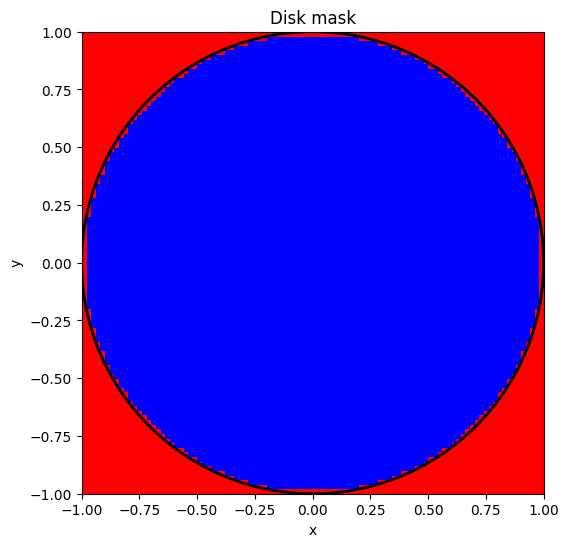

In [244]:
# This is AI-generated plot to see that the logic is correct
from matplotlib.colors import ListedColormap
cmap_rb = ListedColormap(["red", "blue"])

fig, ax = plt.subplots(figsize=(6, 6))

# show outside = red (0), inside = blue (1)
ax.imshow(
    inside.astype(int),
    extent=[-1, 1, -1, 1],
    origin="lower",
    cmap=cmap_rb,
    interpolation="nearest"
)

# draw the boundary of the disk
circle = plt.Circle((0, 0), R, color="black", fill=False, linewidth=2)
ax.add_patch(circle)

ax.set_title("Disk mask")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.show()

Now let's set the boundary conditions for T

In [245]:
T = np.zeros_like(grid)

T[outside] = 100
T[inside] = 0

In [246]:
# I found this cool thing while doomscrolling StackOverflow
# this gives all of the points that have a True (inside the circle) in a [x, y] format. 
# It will be easy to go through them and apply the Laplacian
# Also removes nesting so the code is more readable

inside_vals = np.argwhere(inside)


def applying_heat(T, r, inside_vals):
    T_new = T.copy()

    # we are skipping the boundary rows and columns because 
    # when calculating the laplacian the index will be out of bounds
    skip_these = [0, N-1]

    for i, j in inside_vals:
        if i in skip_these or j in skip_these:
            continue
        T_new[i, j] = r*(T[i+1, j] + T[i-1,j] + T[i, j+1] + T[i, j -1]) + (1-4*r)*T[i,j]
    return T_new

Applying the time variable

In [247]:
# for n in range(t_steps):
#     T = applying_heat(T, r, inside_vals)
#     T[outside] = 100

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML

# Heavy AI-assisted, but it still took me an hour to get it to work and look good

T_anim = np.zeros_like(grid)
T_anim[outside] = 100.0
T_anim[inside] = 0.0

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(
    T_anim, 
    extent=[-1, 1, -1, 1], 
    animated=True,
    cmap='coolwarm',
    origin='lower',
)
circle = plt.Circle((0, 0), R, fill=False, linewidth=2)
ax.add_patch(circle)
ax.set_aspect("equal")
plt.colorbar(im, ax=ax, label="Temperature")

snapshot = 100

def update(frame):
    global T_anim

    for _ in range(snapshot):
        T_anim = applying_heat(T_anim, r, inside_vals)
        T_anim[outside] = 100.0

    im.set_array(T_anim)
    ax.set_title(f"Step {frame+1}/{t_steps}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=t_steps // snapshot,
    interval=40,
    blit=False
)

plt.close(fig)
HTML(ani.to_jshtml())